# Linear Regression

**Objective**

The goal of this lab is to master the art of cleaning and preparing data. Using the California Housing dataset, we will move beyond basic loading to perform outlier detection, feature engineering, and data normalization—essential steps for any high-performing machine learning pipeline.

# 1. Environment & Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [6]:
# Load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

In [7]:
print(f"Dataset Dimensions: {df.shape}")

Dataset Dimensions: (20640, 9)


# 2. Advanced Exploratory Data Analysis (EDA)

In this section, we look for anomalies and distribution patterns.

Task: Visualizing Distributions

Many models assume a normal distribution. Let's check our features.

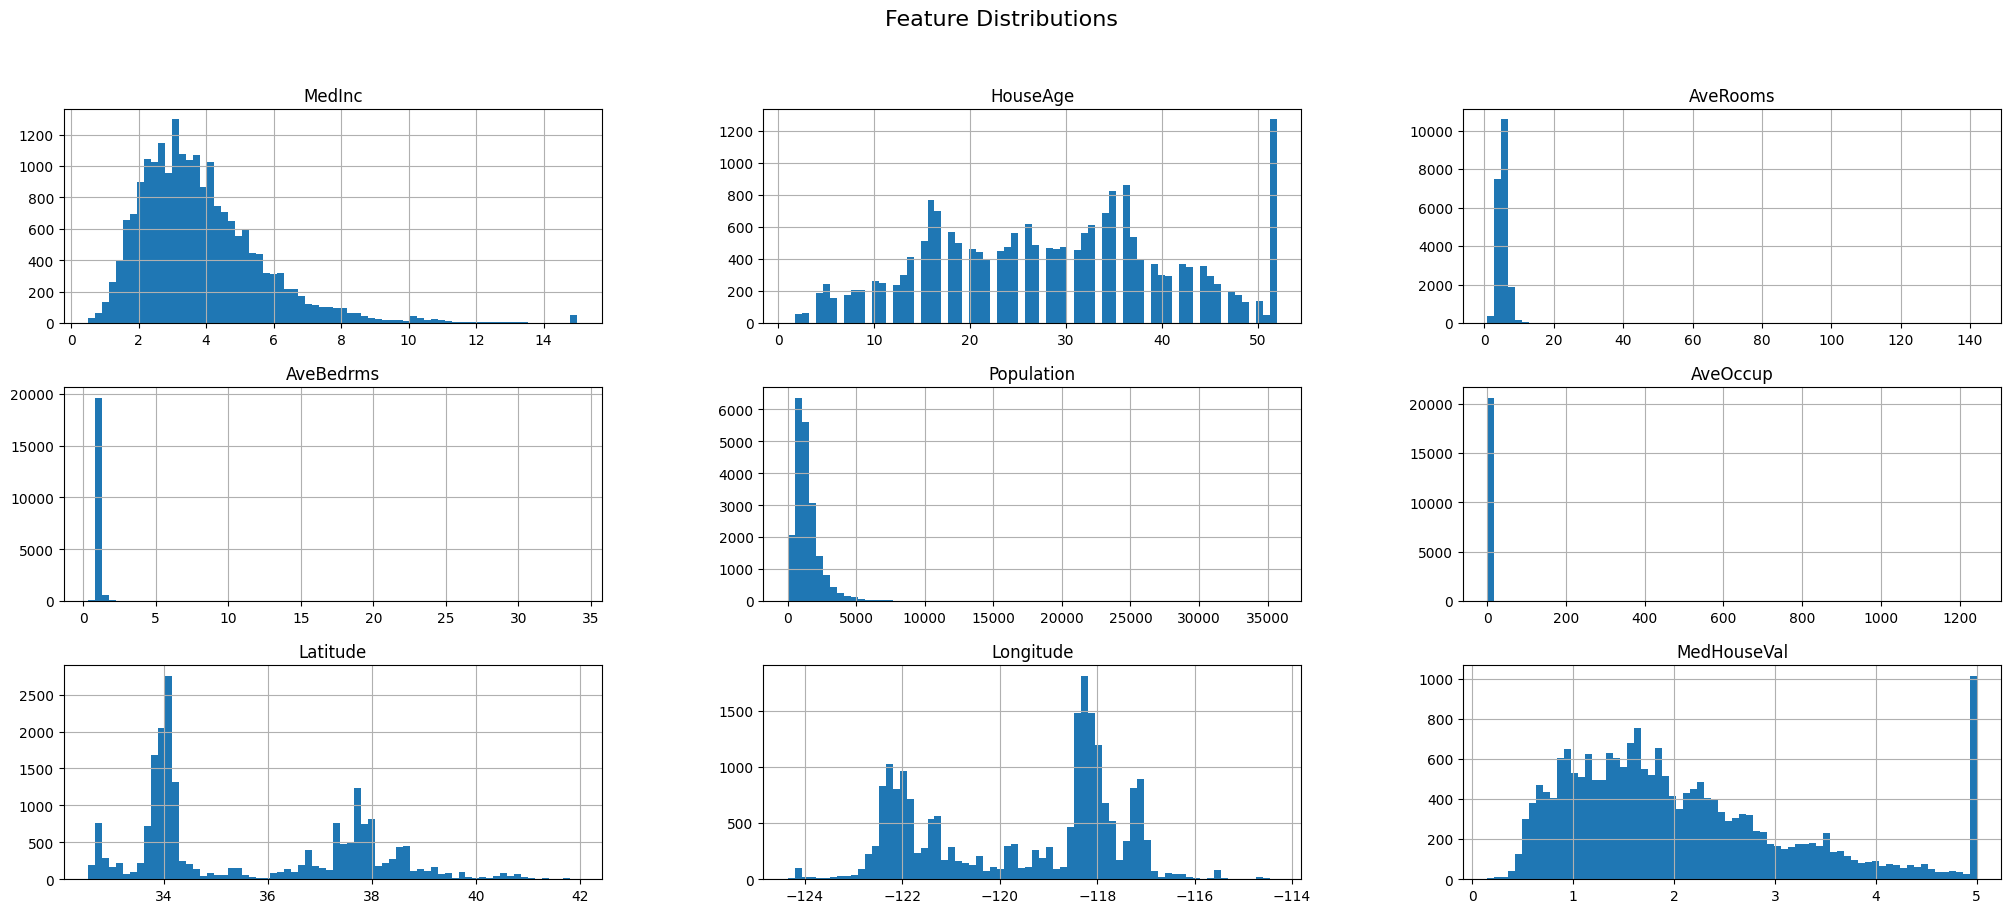

In [8]:
# Plot histograms for all features
df.hist(bins=70, figsize=(25, 10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

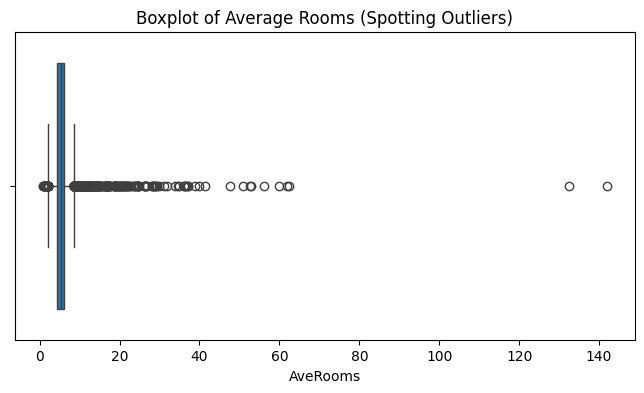

In [9]:
# Boxplot to detect outliers in 'AveRooms'
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['AveRooms'])
plt.title("Boxplot of Average Rooms (Spotting Outliers)")
plt.show()

# 3. Handling Outliers

The California dataset contains extreme values (e.g., houses with 100+ rooms). We need to decide how to handle them.

Task: Capping Outliers

We can use the Interquartile Range (IQR) method to filter or cap outliers.

Implements the Interquartile Range (IQR) Method, a common statistical technique used to identify and remove outliers from a dataset.

In your specific case, it is cleaning the AveRooms column (likely from a housing dataset like California Housing) to remove houses with an unusually high or low number of rooms.

Q1 (25th Percentile): The value below which 25% of the data falls.

Q3 (75th Percentile): The value below which 75% of the data falls

In [10]:
Q1 = df['AveRooms'].quantile(0.25)
Q3 = df['AveRooms'].quantile(0.75)

The IQR represents the range where the "middle 50%" of your data points live. It measures the spread of the bulk of your data.
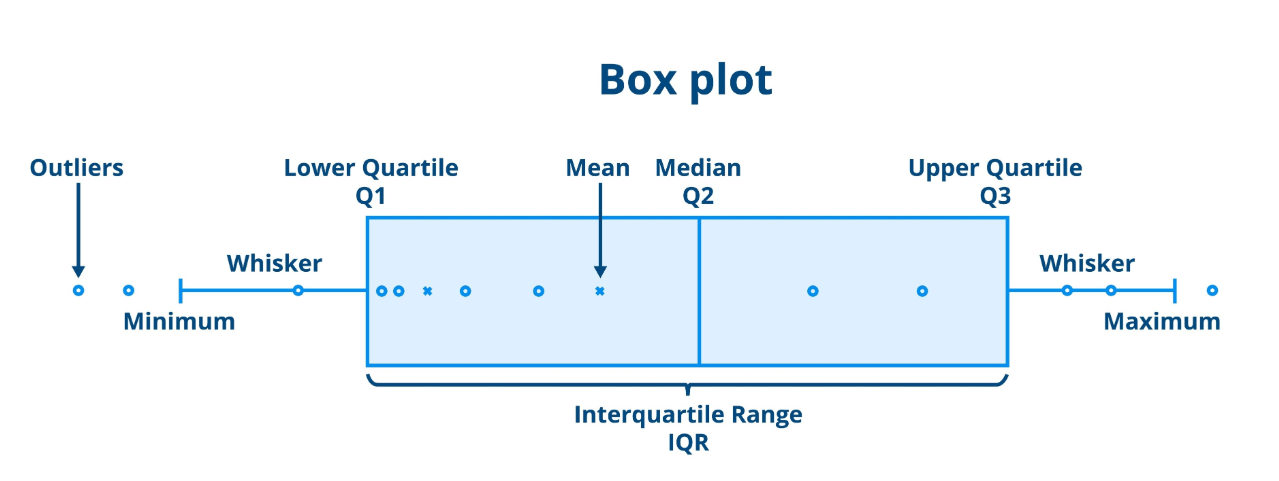

Statistically, any data point that falls significantly outside the central bulk is considered an outlier. The 1.5 multiplier is the standard rule:

Lower Bound: Anything smaller than this is an outlier (e.g., a "house" with 0.1 rooms).

Upper Bound: Anything larger than this is an outlier (e.g., a mansion with 50 rooms in a middle-class neighborhood).

In [11]:
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

New DataFrame (df_filtered) that only includes rows where the AveRooms value sits comfortably between the lower and upper fences.

In [12]:
# Filter the dataframe
df_filtered = df[(df['AveRooms'] >= lower_bound) & (df['AveRooms'] <= upper_bound)]

In [13]:
print(f"Original size: {len(df)}")
print(f"Filtered size: {len(df_filtered)}")

Original size: 20640
Filtered size: 20129


# 4. Feature Engineering

Creating new features can often provide more predictive power than raw data alone.

Task: Creating Derived Features

Rooms per Household: AveRooms / AveOccup

Bedroom Ratio: AveBedrms / AveRooms

1. Creating 'RoomsPerPerson

**The Logic:** AveRooms tells you the size of the house, and AveOccup tells you how many people live there.

**The "Why":** A 5-room house is "crowded" if 10 people live there, but "spacious" if only 2 people live there. By dividing them, you create a measure of living density.

**ML Impact:** High density (low RoomsPerPerson) usually correlates with lower property values.

In [14]:
df_filtered['RoomsPerPerson'] = df_filtered['AveRooms'] / df_filtered['AveOccup']

/tmp/ipykernel_5363/1634574969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['RoomsPerPerson'] = df_filtered['AveRooms'] / df_filtered['AveOccup']


2. Creating 'BedroomRatio'

**The Logic:** This calculates what percentage of the total rooms in the house are actually bedrooms.

**The "Why":** This helps distinguish between different types of architecture. A high ratio might indicate a specialized residential home, while a lower ratio might suggest a house with many "extra" rooms like study areas, dining rooms, or large living spaces.

**ML Impact:** This helps the model understand the utility of the house layout.

In [15]:
df_filtered['BedroomRatio'] = df_filtered['AveBedrms'] / df_filtered['AveRooms']

/tmp/ipykernel_5363/747306845.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['BedroomRatio'] = df_filtered['AveBedrms'] / df_filtered['AveRooms']


The .describe() function provides a statistical summary of these two new columns. It will output:

count: How many rows have data.

mean: The average ratio across the whole dataset.

std: How much the ratios vary (Standard Deviation).

min / max: The smallest and largest values.

25%, 50%, 75%: The Quantiles (which you just learned about!) to help you see the distribution and identify if there are still outliers in your new features.

In [17]:
print(df[['RoomsPerPerson', 'BedroomRatio']].describe())

KeyError: "None of [Index(['RoomsPerPerson', 'BedroomRatio'], dtype='object')] are in the [columns]"

# 5. Feature Scaling

Features like Population (thousands) and MedInc (units) have vastly different scales. This can bias certain algorithms.

Task: Comparing Scalers

We will compare StandardScaler (Z-score) and MinMaxScaler (0-1 range).

**Why Scale Data?**

Most machine learning algorithms (like Linear Regression, SVM, or K-Means) perform poorly if one feature has a very large range (e.g., Income in thousands) and another has a small range (e.g., number of rooms). Scaling ensures that all features are treated with equal importance by the model.

The Math: It shifts the distribution so the Mean is 0 and the Standard Deviation is

1.Formula: $z = \frac{x - \mu}{\sigma}$

Result: Most values will fall between $-3$ and $+3$. It does not have a fixed minimum or maximum.

Best Use: Use this if your data follows a Normal (Gaussian) distribution. It is more robust to outliers than MinMax scaling.

In [26]:
# Initialize scalers
std_scaler = StandardScaler()
df['MedInc_StdScaled'] = std_scaler.fit_transform(df[['MedInc']])


The Math: It squashes all values into a fixed range, usually exactly between 0 and 1.

Formula: $x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$

Result: The smallest value in your data becomes $0$, and the largest becomes $1$.

Best Use: Use this when you need a bounded range (like in Neural Networks or Image Processing) or when you know the data does not follow a normal distribution.

In [27]:
# Scaling 'MedInc'
minmax_scaler = MinMaxScaler()
df['MedInc_MinMaxScaled'] = minmax_scaler.fit_transform(df[['MedInc']])

Matplotlib and Seaborn to create side-by-side histograms:

subplots(1, 2): Creates a layout with 1 row and 2 columns.

kde=True: Adds a "Kernel Density Estimate" line (the smooth curve over the bars) to show the shape of the distribution.

The Comparison: When you run this, you will notice that the shape of the two graphs looks identical, but the numbers on the X-axis are very different.

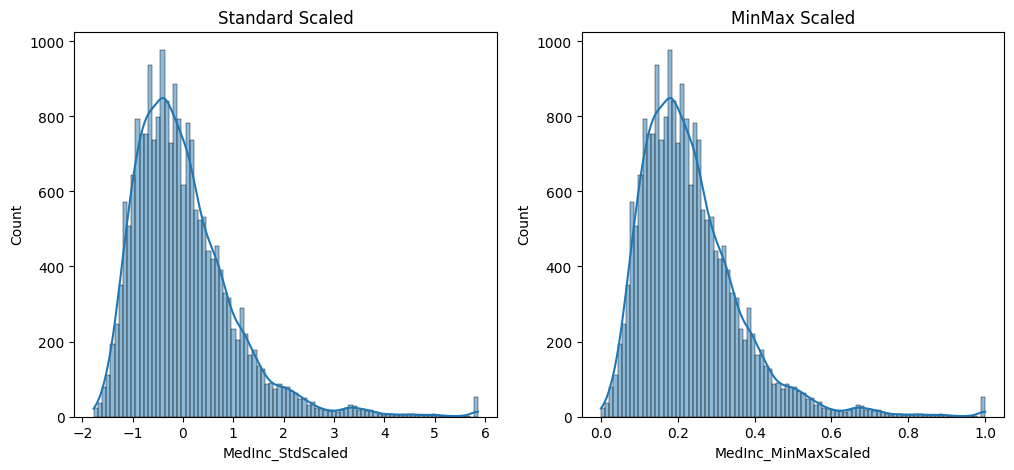

In [28]:
# Visualize the difference
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['MedInc_StdScaled'], ax=ax[0], kde=True).set_title("Standard Scaled")
sns.histplot(df['MedInc_MinMaxScaled'], ax=ax[1], kde=True).set_title("MinMax Scaled")
plt.show()

**Objective**

In this lab, you will explore advanced data transformation techniques. Specifically, you will learn how to use Principal Component Analysis (PCA) to reduce feature dimensionality and One-Hot Encoding to transform geographic coordinates into categorical regions.

**Setup and Data Preparation**

We will continue using the California Housing dataset, ensuring our previous preprocessing steps (like feature engineering) are included.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

We are loading the standard California Housing dataset and adding the target variable (MedHouseVal).

We are recreating the ratios we discussed earlier (RoomsPerPerson and BedroomRatio). These new features often provide more "signal" to a model than raw counts.

In [19]:
# Load and basic engineering from previous lab
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target
df['RoomsPerPerson'] = df['AveRooms'] / df['AveOccup']
df['BedroomRatio'] = df['AveBedrms'] / df['AveRooms']

axis=1: Tells Pandas to drop a column, not a row.

The Logic: When performing PCA or training a model, you must separate your "Features" (the inputs, like income and location) from your "Target" (the output you want to predict, like house price).

In [20]:
# Scaling is MANDATORY for PCA
features = df.drop('MedHouseVal', axis=1)

PCA works by identifying the directions (principal components) along which the data varies the most.

If one feature has a huge range (like Population in the thousands) and another has a tiny range (like AveRooms from 1 to 10), PCA will "think" the larger numbers are more important simply because their variance is mathematically higher.

Standardizing ensures all features are on the same scale, allowing PCA to treat them fairly based on their actual relationship, not their units.

In [21]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

**Principal Component Analysis (PCA)**

PCA helps us reduce the number of variables while retaining most of the original variance.

Task: Finding the Right Number of Components

We calculate the "Explained Variance Ratio" to see how much information each principal component holds.

**The Logic:** By not specifying the number of components (n_components), PCA calculates all possible components (one for every feature in your data).

**The Goal**: We aren't transforming the data yet; you are just "learning" how much information each component captures.

In [22]:
pca = PCA()
pca.fit(scaled_features)

PCA()

pca.explained_variance_ratio_: This tells you the percentage of the dataset's total variance "captured" by each individual component.

np.cumsum(...): This calculates the running total. For example, if Component 1 explains 40% and Component 2 explains 30%, the cumulative sum at step 2 is 70%.

The "Elbow" Method: You use this plot to find the "elbow" or the point where the curve flattens out. This tells you how many components you need to represent, say, 90% of your original data's information.

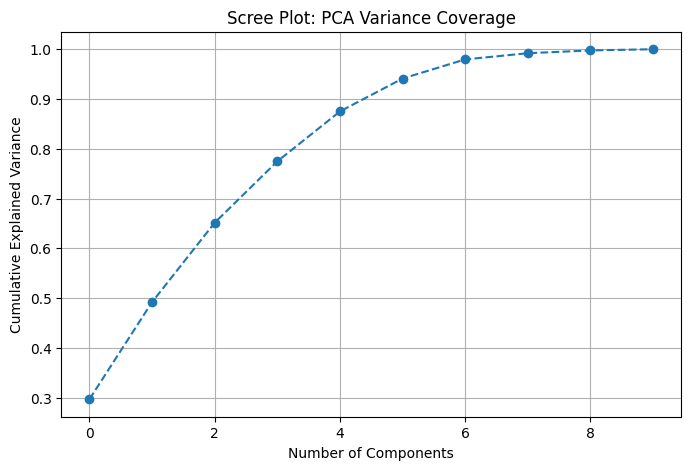

In [23]:
# Plotting the Cumulative Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: PCA Variance Coverage')
plt.grid()
plt.show()

**The Decision:** Based on the plot, the code decides to keep only the top 3 components.

**The Transformation:** fit_transform actually projects your original 10+ features into a new 3D space. These 3 "Principal Components" are mathematical combinations of your original features (like income, rooms, and location).

In [24]:
# Transform data to the first 3 components
pca_reduced = PCA(n_components=3)
X_pca = pca_reduced.fit_transform(scaled_features)

riginal: Likely (20640, 10) if you used the California dataset with your engineered ratios.

Reduced: (20640, 3).

The Benefit: Your model now has 70% fewer columns to process. This significantly reduces the risk of overfitting and speeds up training time.

In [25]:
print(f"Original shape: {scaled_features.shape}")
print(f"Reduced shape: {X_pca.shape}")

Original shape: (20640, 10)
Reduced shape: (20640, 3)


**Advanced Encoding: Binning & One-Hot Encoding**

Sometimes raw coordinates (Latitude/Longitude) are too granular. Binning them into "Regions" can help a model generalize better.

Task: Creating Geographic Clusters

We will bin coordinates into a grid and then apply One-Hot Encoding.

Implements Geographic Binning and Categorical Encoding. It is a sophisticated way to turn raw GPS coordinates (Latitude and Longitude) into meaningful "neighborhood" categories that a Machine Learning model can understand.

The Logic: Raw coordinates are too specific (every house has a slightly different lat/long). pd.cut divides the entire range of California's latitude and longitude into 10 equal-sized "buckets" or bins.

The Result: Instead of 34.0522, a location might just be in "Latitude Bin 3." This groups nearby houses into the same grid square.

In [26]:
# Create simple 10x10 grid bins for California
df['Lat_Bin'] = pd.cut(df['Latitude'], bins=10, labels=False)
df['Lon_Bin'] = pd.cut(df['Longitude'], bins=10, labels=False)

The Logic: This combines the Latitude bin and Longitude bin into a single string (e.g., "3_5").

The Result: Each unique string represents one specific square tile on a 10x10 map of California. This "Region_ID" acts as a categorical name for a specific geographic area.

In [27]:
df['Region_ID'] = df['Lat_Bin'].astype(str) + "_" + df['Lon_Bin'].astype(str)

The Problem: Machine Learning models can't do math on strings like "3_5".

The Solution: One-Hot Encoding creates new columns for each region. If a house is in Region "3_5", that column gets a 1, and all other region columns get a 0.

max_categories=10: This is a crucial safety step. Since a 10x10 grid could create 100 regions, this limits the encoder to only the top 10 most frequent regions (densely populated areas). All other sparse regions are lumped into an "infrequent" category. This prevents the "Curse of Dimensionality" and overfitting.

In [28]:
# Apply One-Hot Encoding to the Region_ID
encoder = OneHotEncoder(sparse_output=False, max_categories=10)
region_encoded = encoder.fit_transform(df[['Region_ID']])

The raw NumPy array from the encoder back into a clean Pandas DataFrame with descriptive column names like Region_ID_3_5, Region_ID_4_2, etc.

In [29]:
# Create a DataFrame with the encoded regions
region_df = pd.DataFrame(
    region_encoded,
    columns=encoder.get_feature_names_out(['Region_ID'])
)

In [30]:
print("Top 10 Geographic Regions (One-Hot Encoded):")
print(region_df.head())

Top 10 Geographic Regions (One-Hot Encoded):
   Region_ID_0_7  Region_ID_1_5  Region_ID_1_6  Region_ID_1_7  Region_ID_4_4  \
0            0.0            0.0            0.0            0.0            0.0   
1            0.0            0.0            0.0            0.0            0.0   
2            0.0            0.0            0.0            0.0            0.0   
3            0.0            0.0            0.0            0.0            0.0   
4            0.0            0.0            0.0            0.0            0.0   

   Region_ID_5_1  Region_ID_5_2  Region_ID_5_3  Region_ID_6_2  \
0            0.0            1.0            0.0            0.0   
1            0.0            1.0            0.0            0.0   
2            0.0            1.0            0.0            0.0   
3            0.0            1.0            0.0            0.0   
4            0.0            1.0            0.0            0.0   

   Region_ID_infrequent_sklearn  
0                           0.0  
1              

**Visualizing PCA Components**

To understand what the PCA components represent, we can look at the "loadings" (how much each original feature contributes to a component).

In [31]:
loadings = pd.DataFrame(
    pca_reduced.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=features.columns
)

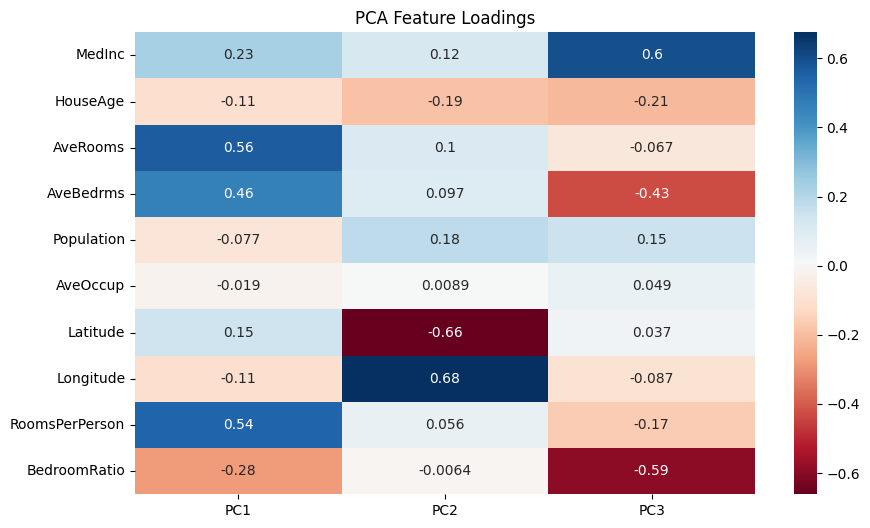

In [32]:
plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu')
plt.title("PCA Feature Loadings")
plt.show()

**Integrated Data Preparation**

We will merge our engineered features, PCA components, and one-hot encoded regions into a single "Master" feature set.

In [33]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
# 1. Load and Standardize
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Data Preparation & Engineering

The Logic: You are loading the raw data and immediately creating Domain-Specific Ratios.

The Goal: As we discussed in your previous labs, these ratios (like density and layout utility) are often more correlated with house prices than raw counts like "Total Bedrooms."

In [35]:
# 2. Add Engineered Ratios
X['RoomsPerPerson'] = X['AveRooms'] / X['AveOccup']
X['BedroomRatio'] = X['AveBedrms'] / X['AveRooms']

Global Trend Capture (PCA)

The Logic: You standardize all features and then use Principal Component Analysis to extract the two most significant "directions" of variance in the data.

The Goal: These two components (PC1, PC2) act as "super-features" that summarize the overall state of a housing record, reducing noise while keeping the most important information.

In [36]:
# 3. Create PCA Components (Top 2)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_cols = ['PC1', 'PC2']

**Spatial Pattern Capture (Geographic Binning)**

The Logic: You divide California into 5 horizontal "Latitude strips." Then, you use One-Hot Encoding to turn these strips into binary columns.

The Goal: This helps the model understand that being in "Northern California" vs. "Southern California" might have a distinct, non-linear impact on price that raw latitude numbers alone can't easily represent.

In [37]:
# 4. Create Geographic Bins (Simplified for focus)
X['Lat_Bin'] = pd.cut(X['Latitude'], bins=5, labels=False)
encoder = OneHotEncoder(sparse_output=False)
geo_encoded = encoder.fit_transform(X[['Lat_Bin']])
geo_cols = [f'Region_{i}' for i in range(geo_encoded.shape[1])]

**The Logic:** np.hstack (Horizontal Stack) glues all your different transformations together into one massive matrix.

The Breakdown of X_final:

Original Features (Scaled): Income, age, rooms, etc.

Engineered Ratios (Scaled): Rooms per person, bedroom ratio.

PCA Components: Summarized global trends.

Geographic Bins: Location-based categories.

In [38]:
# Combine everything into a final Feature Set
X_final = np.hstack([X_scaled, X_pca, geo_encoded])
feature_names = list(X.columns) + pca_cols + geo_cols

The Logic: You set aside 20% of this highly engineered data for testing.

The Goal: This allows you to evaluate your model on unseen data to check for overfitting. Since you have added so many features, checking for overfitting is now more important than ever!

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

**Linear Regression vs. Ridge vs. Lasso**

When we have many features (some highly correlated, like raw features and their PCA components), standard OLS Linear Regression can become unstable.

Task: Training the Models

We will compare standard Linear Regression with Ridge ($L_2$ regularization) and Lasso ($L_1$ regularization).

Initializing the Three Models
You are comparing three variations of linear regression:

Ordinary Least Squares (OLS) - LinearRegression()
The Logic: This is the "basic" model. It tries to minimize the sum of squared errors between predictions and actual values without any restrictions.

The Risk: Since you just added many features (PCA, Geographic Bins, Ratios), OLS is highly susceptible to Overfitting. It might assign very large weights to noisy features.

Ridge Regression (L2 Regularization)
The Logic: Ridge(alpha=1.0) adds a penalty proportional to the square of the magnitude of coefficients.

The Ridge Regression Formula (L2)In Ridge regression, the model tries to minimize the sum of squared errors plus a penalty term:$$Loss = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} w_j^2$$$\sum (y_i - \hat{y}_i)^2$: The standard OLS error (Residual Sum of Squares).$\alpha$: The complexity parameter (the "knob" you turn).$\sum w_j^2$: The sum of the squares of the coefficients (weights).

The Goal: It forces the model to keep the weights small and spread out. It prevents any single feature (like a specific geographic bin) from dominating the prediction.

Lasso Regression (L1 Regularization)
The Logic: Lasso(alpha=0.01) adds a penalty proportional to the absolute value of the coefficients.

In Lasso, the penalty uses the absolute values of the weights instead of the squares:$$Loss = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |w_j|$$$|w_j|$: The absolute value of the weight. This is what allows Lasso to shrink coefficients all the way to zero.

The Goal: Lasso can shrink unimportant feature coefficients all the way to zero. It effectively performs Automatic Feature Selection. If some of your PCA components or bins are useless, Lasso will simply ignore them.

In [44]:
# Initialize models
lr = LinearRegression()
ridge = Ridge(alpha=0.01)
lasso = Lasso(alpha=1.01)

The .fit() command is where the "learning" happens. The models look at your X_train matrix (which contains your scaled data, PCA, and bins) and calculate the optimal weights to predict the house prices (y_train).

In [45]:
# Fit models
lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

Lasso(alpha=1.01)

using two key metrics to judge performance on the unseen test data:$R^2$ Score (Coefficient of Determination): Tells you what percentage of the variance in house prices is explained by the model. 1.0 is perfect; 0.0 means the model is just guessing the average.

Mean Squared Error (MSE): Measures the average squared difference between the estimated values and the actual value. Lower is better.

In [46]:
# Evaluate
def get_metrics(model, X, y):
    pred = model.predict(X)
    return r2_score(y, pred), mean_squared_error(y, pred)

Interpreting the ResultsWhen you run the print statements:If OLS has a much higher $R^2$ on Train than on Test: You are overfitting.

If Ridge/Lasso have better Test $R^2$ than OLS: The regularization is working! It is successfully ignoring the noise in your engineered features to provide a more "generalized" model.

In [47]:
print(f"OLS R2: {get_metrics(lr, X_test, y_test)[0]:.4f}")
print(f"Ridge R2: {get_metrics(ridge, X_test, y_test)[0]:.4f}")
print(f"Lasso R2: {get_metrics(lasso, X_test, y_test)[0]:.4f}")

OLS R2: 0.6602
Ridge R2: 0.6602
Lasso R2: -0.0002


Since you used alpha=1.0 for Ridge and alpha=0.01 for Lasso, you are applying a relatively light touch of regularization. You would typically use Cross-Validation (like RidgeCV or LassoCV) to find the perfect alpha value instead of guessing.

 **Interpreting Model Weights**

The main advantage of Lasso is that it performs Feature Selection by shrinking less important coefficients to exactly zero.

In [48]:
import matplotlib.pyplot as plt

Every linear model assigns a "weight" (coefficient) to every feature. A positive weight means the feature increases house price; a negative weight decreases it.

The Comparison: By plotting them side-by-side, you can see how Regularization changes these weights:

OLS (Circles): Usually has the most "scattered" points. It might assign very high weights to noisy features because it has no penalty.

Ridge (Squares): You will notice the squares are generally closer to the zero line (the black dashed line) than the OLS circles. It "shrinks" the weights to prevent any one feature from being too influential.

Lasso (Triangles): This is the most interesting. Many of the triangles will sit exactly on the zero line.

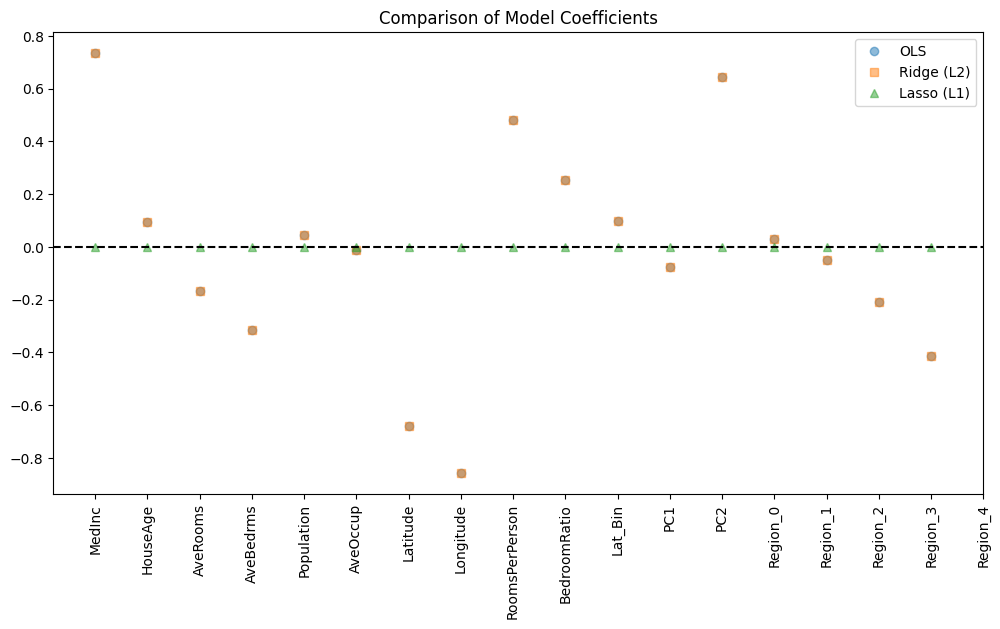

In [49]:

# Compare coefficients
plt.figure(figsize=(12, 6))
plt.plot(lr.coef_, 'o', label='OLS', alpha=0.5)
plt.plot(ridge.coef_, 's', label='Ridge (L2)', alpha=0.5)
plt.plot(lasso.coef_, '^', label='Lasso (L1)', alpha=0.5)
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.axhline(0, color='black', linestyle='--')
plt.title("Comparison of Model Coefficients")
plt.legend()
plt.show()

xticks: This labels the X-axis with your specific feature names (e.g., MedInc, PC1, Region_0). Rotating them 90 degrees makes them readable.

axhline(0): This draws a horizontal "baseline." Any point on this line has a weight of zero, meaning the feature has no impact on the prediction.

Lasso (L1) has a unique mathematical property: it can force coefficients to be exactly zero. This is called Sparsity.

The Goal: This line of code creates a list of only the features that Lasso "decided" were actually useful for predicting house prices.

In [52]:
# List features Lasso kept
important_features = [name for name, coef in zip(feature_names, lasso.coef_) if abs(coef) > 0]
print(f"Lasso kept {len(important_features)} out of {len(feature_names)} features.")

Lasso kept 0 out of 18 features.


 **Hyperparameter Tuning: The Alpha Parameter**

The strength of regularization is controlled by alpha.

alpha = 0: Same as OLS.

alpha = Large: All coefficients go to zero (High Bias).

Hyperparameter Tuning experiment. It specifically investigates the Regularization Strength ($\alpha$) of the Ridge model to find the "Goldilocks" zone—the point where the model is complex enough to learn patterns but restricted enough to avoid overfitting.

Notice these values increase by powers of 10. This is called a Logarithmic Scale. It allows you to test a very wide range of strengths, from almost no regularization ($0.001$) to extremely aggressive smoothing ($100$).

In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_scores = []

The Iterative Training Loop

 For every $\alpha$ in your list, the code:

 Initializes a new Ridge model with that specific $\alpha$.

 Trains (fit) the model using your highly engineered training data.

 Calculates the $R^2$ score on the Testing Set (unseen data).

 The Goal: You are recording how well the model generalizes to new data as you turn the "regularization knob."

In [ ]:
for a in alphas:
    m = Ridge(alpha=a).fit(X_train, y_train)
    ridge_scores.append(m.score(X_test, y_test))

plt.xscale('log'): This is crucial. Because your $\alpha$ values range from $0.001$ to $100$, a standard linear scale would bunch all the small values together at the far left. A log scale spreads them out evenly so you can see the trend clearly.

marker='x': Places a small 'x' at each of your tested data points.

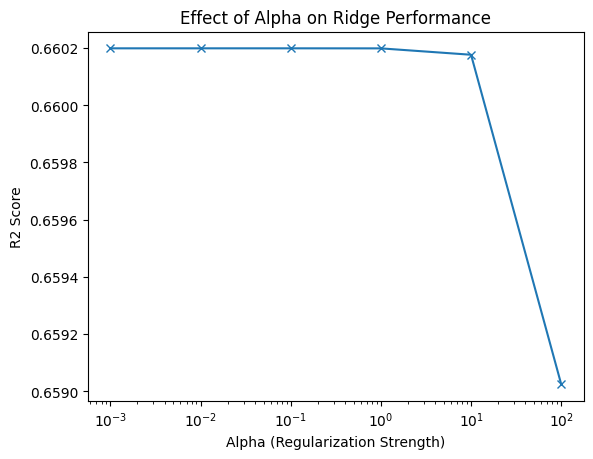

In [ ]:
plt.plot(alphas, ridge_scores, marker='x')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R2 Score')
plt.title('Effect of Alpha on Ridge Performance')
plt.show()

**Exercise 1: Analyzing Lasso Sparsity**

The goal is to find the specific alpha value where the model simplifies to only the 3 most "important" features.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

np.linspace(0.01, 1.0, 100): This creates a list of 100 evenly spaced penalty strengths between 0.01 (weak) and 1.0 (strong).The Logic: Instead of guessing one $\alpha$, you are preparing to test a wide spectrum of "pressure" on the model.

In [ ]:
# We assume X_train, y_train, and feature_names are available from the previous lab
alphas = np.linspace(0.01, 1.0, 100)
n_features = []

lasso.coef_ != 0: This creates a boolean mask (True/False) for every feature.

np.sum(...): Since Python treats True as 1 and False as 0, this counts exactly how many features "survived" the Lasso penalty at that specific $\alpha$.

The Trend: As $\alpha$ increases, the number of non-zero features will decrease. This is because a stronger penalty forces more coefficients to zero.

In [ ]:
for a in alphas:
    lasso = Lasso(alpha=a).fit(X_train, y_train)
    n_features.append(np.sum(lasso.coef_ != 0))

np.where(...) == 3: This searches your n_features list for the first instance where exactly three features remained in the model.

The Logic: You are essentially saying: "Show me the exact amount of pressure I need to apply so that only the three strongest features can survive."

You retrain the model using that specific target_alpha.

List Comprehension: This pulls out the names of the features that didn't get "zeroed out." In your dataset, these are likely to be MedInc (Median Income) and perhaps your engineered PC1 or RoomsPerPerson.

In [ ]:
# Find the alpha where n_features == 3
target_alpha = alphas[np.where(np.array(n_features) == 3)[0][0]]
final_lasso = Lasso(alpha=target_alpha).fit(X_train, y_train)
top_3 = [name for name, coef in zip(feature_names, final_lasso.coef_) if coef != 0]

In [ ]:
print(f"Alpha for 3 features: {target_alpha:.4f}")
print(f"Top 3 Features: {top_3}")

Alpha for 3 features: 0.1100
Top 3 Features: ['MedInc', 'HouseAge', 'BedroomRatio']


**Exercise 2: Testing PCA Redundancy**

Does adding PCA components actually help if we already have the raw features? We compare two Ridge models.

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
# Model A: Raw Features + Engineered Ratios + Geo Bins (No PCA)
# Indices for non-PCA columns (excluding PC1, PC2 which are at the end of raw features)
X_no_pca = np.delete(X_train, [len(X.columns), len(X.columns)+1], axis=1)
X_test_no_pca = np.delete(X_test, [len(X.columns), len(X.columns)+1], axis=1)

In [ ]:
ridge_full = Ridge(alpha=1.0).fit(X_train, y_train)
ridge_no_pca = Ridge(alpha=1.0).fit(X_no_pca, y_train)


In [ ]:
print(f"R2 with PCA: {ridge_full.score(X_test, y_test):.4f}")
print(f"R2 without PCA: {ridge_no_pca.score(X_test_no_pca, y_test):.4f}")

R2 with PCA: 0.6602
R2 without PCA: 0.6602


**Exercise 3: Automated Hyperparameter Tuning**

Instead of guessing alpha, we use RidgeCV and LassoCV which use efficient Leave-One-Out or K-Fold Cross-Validation.

 represents the Gold Standard for model training in Machine Learning. Instead of you manually guessing the best $\alpha$ (as we did in previous labs with loops), you are now using Cross-Validation (CV) to let the computer find the mathematically optimal penalty for you.

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV

provide a list of potential $\alpha$ values. RidgeCV performs an internal "Leave-One-Out" Cross-Validation by default.The Result: It tries every value in your list and saves the one that results in the lowest error. ridge_cv.alpha_ reveals the "winner."

In [ ]:
# RidgeCV automatically tests a range of alphas
ridge_cv = RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10, 100]).fit(X_train, y_train)
print(f"Best Ridge Alpha: {ridge_cv.alpha_}")

Best Ridge Alpha: 100.0


Unlike Ridge, you don't even have to provide a list. LassoCV is smarter—it explores the "Lasso Path" (the range of alphas where coefficients start dropping to zero) automatically.

cv=5: It splits the training data into 5 parts, training on 4 and validating on 1, rotating this process 5 times.

In [ ]:
# LassoCV explores the path of alphas automatically
lasso_cv = LassoCV(cv=5, random_state=42).fit(X_train, y_train)
print(f"Best Lasso Alpha: {lasso_cv.alpha_:.6f}")

Best Lasso Alpha: 0.001058


In [ ]:
# Final Performance Comparison
print(f"Optimized Ridge R2: {ridge_cv.score(X_test, y_test):.4f}")
print(f"Optimized Lasso R2: {lasso_cv.score(X_test, y_test):.4f}")


Optimized Ridge R2: 0.6590
Optimized Lasso R2: 0.6598
